### TC.4 - 

Conforme dito, um dos aspectos marcantes nos conteúdos textuais é a elevada variedade. Selecione
uma obra literária de domínio público (e.g., livros tais como Vinte mil léguas submarinas (de Júlio
Verne), a Bíblia, etc.) e ilustre a variedade de dados presente. Considere, por exemplo a construção
de frases, orações etc. e compare com expressões de uso corrente. Para respaldar sua resposta,
elabore um programa que contabilize, por exemplo, o número de palavras diferentes e faça um
gráfico das palavras mais frequentes e das palavras menos frequentes.

In [10]:
#Instalação de Dependências

#!pip -q install pypdf nltk matplotlib pandas

import re 
from collections import Counter
from nltk.corpus import stopwords

import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Novale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Novale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Novale\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [6]:
# Leitura de PDF

from pypdf import PdfReader

CAMINHO_DO_PDF = "machado-de-assis-a-cartomante.pdf" 

reader = PdfReader(CAMINHO_DO_PDF)
paginas = []
for i, page in enumerate(reader.pages):
    txt = page.extract_text() or ""
    paginas.append(txt)

texto_bruto = "\n".join(paginas)
len(texto_bruto), texto_bruto[:500]

(19484,
 'A Cartomante, Machado de Assis \n \nFonte: \nASSIS, Machado de. Obra Completa. Rio de Janeiro : Nova Aguilar 1994. v. II.  \n \nTexto proveniente de: \nA Biblioteca Virtual do Estudante Brasileiro <http://www.bibvirt.futuro.usp.br> \nA Escola do Futuro da Universidade de São Paulo \nPermitido o uso apenas para fins educacionais. \n \nTexto-base digitalizado por: \nNúcleo de Pesquisas em Informática, Literatura e Lingüística \n(http://www.cce.ufsc.br/~nupill/literatura/literat.html) \n \nEste material pode ser')

In [7]:
# Limpeza de Texto
# A limpeza vai ser crucial para reduzir ruídos como quebras de linha, pontuações e caracteres especiais, deixando apenas as palavras para análise.


def limpar_texto(texto):
    # Remove hifenização no fim de linha: "exem-\nplo" -> "exemplo"
    texto = re.sub(r"-\s*\n\s*", "", texto)

    # Troca quebras de linha por espaço
    texto = re.sub(r"\s*\n\s*", " ", texto)

    # Normaliza espaços
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

texto = limpar_texto(texto_bruto)
len(texto), texto[:500]

(18941,
 'A Cartomante, Machado de Assis Fonte: ASSIS, Machado de. Obra Completa. Rio de Janeiro : Nova Aguilar 1994. v. II. Texto proveniente de: A Biblioteca Virtual do Estudante Brasileiro <http://www.bibvirt.futuro.usp.br> A Escola do Futuro da Universidade de São Paulo Permitido o uso apenas para fins educacionais. Texto-base digitalizado por: Núcleo de Pesquisas em Informática, Literatura e Lingüística (http://www.cce.ufsc.br/~nupill/literatura/literat.html) Este material pode ser redistribuído livr')

In [8]:
# Nessa celula irei ilustrar a variedade estrutural comparando o tamanho das sentenças (em tokens/palavras) do livro com “expressões de uso corrente”.

sentencas = nltk.sent_tokenize(texto)

# Tokenizador simples de "palavras": letras (inclui acentos) e apóstrofo
TOKEN_RE = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ']+")

def tokens_de_uma_sentenca(s: str):
    return TOKEN_RE.findall(s.lower())

tamanhos_sentencas = [len(tokens_de_uma_sentenca(s)) for s in sentencas if s.strip()]
len(sentencas), sum(tamanhos_sentencas)/len(tamanhos_sentencas)

expressoes_correntes = [
    "bom dia, tudo bem?",
    "quanto custa isso?",
    "eu acho que sim",
    "não tenho certeza",
    "me desculpe, não entendi",
    "me manda por favor",
    "obrigado, de verdade",
    "a gente se fala depois",
    "não faz sentido",
    "pode repetir?"
]

tam_exp = [len(tokens_de_uma_sentenca(s)) for s in expressoes_correntes]

print("Média de palavras por sentença (livro):", round(sum(tamanhos_sentencas)/len(tamanhos_sentencas), 2))
print("Média de palavras por sentença (expressões):", round(sum(tam_exp)/len(tam_exp), 2))

Média de palavras por sentença (livro): 15.3
Média de palavras por sentença (expressões): 3.5


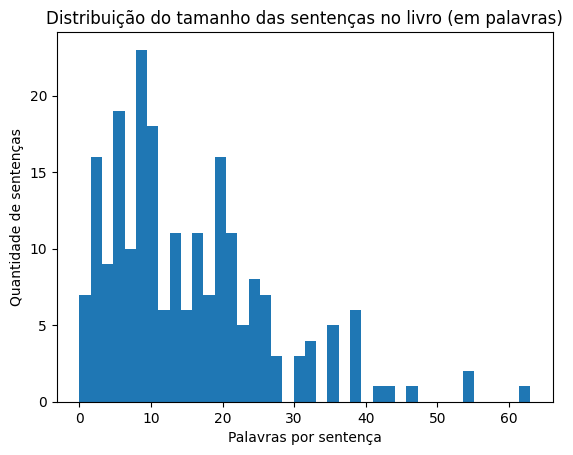

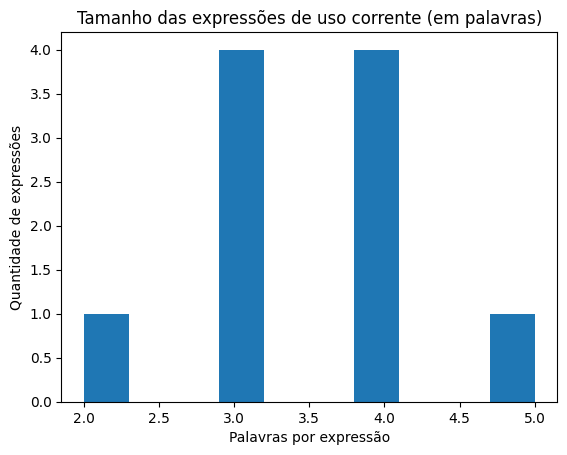

In [9]:
# Histograma Comparativo

plt.figure()
plt.hist(tamanhos_sentencas, bins=40)
plt.title("Distribuição do tamanho das sentenças no livro (em palavras)")
plt.xlabel("Palavras por sentença")
plt.ylabel("Quantidade de sentenças")
plt.show()

plt.figure()
plt.hist(tam_exp, bins=10)
plt.title("Tamanho das expressões de uso corrente (em palavras)")
plt.xlabel("Palavras por expressão")
plt.ylabel("Quantidade de expressões")
plt.show()

In [11]:
# Métricas de variedade lexical

# Total de Palavras = token
# Palavras diferentes = vocab
# Type-Token Ratio (TTR) = vocab/tokens -> quanto maior, mais variedade lexical
# Hapax = palavras que aparecem apenas 1 vez -> indica riqueza no vocabulário

tokens = TOKEN_RE.findall(texto.lower())
total_tokens = len(tokens)

contagem = Counter(tokens)
vocab = len(contagem)

hapax = sum(1 for palavra, freq in contagem.items() if freq == 1)

trr = vocab / total_tokens if total_tokens else 0
hapax_ratio = hapax / vocab if vocab else 0

print("Total de palavras (tokens):", total_tokens)
print("Palavras diferentes (vocab):", vocab)
print("Type-Token Ratio (TTR):", round(trr, 4))
print("Hapax (palavras únicas):", hapax, "| Hapax Ratio:", round(hapax_ratio, 4))

Total de palavras (tokens): 3320
Palavras diferentes (vocab): 1183
Type-Token Ratio (TTR): 0.3563
Hapax (palavras únicas): 807 | Hapax Ratio: 0.6822


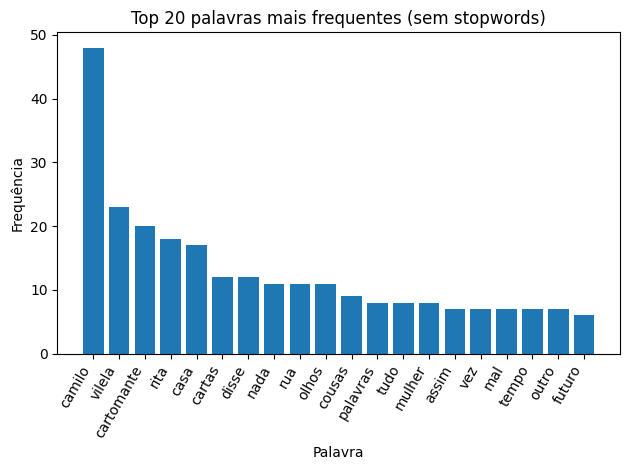

,Palavra,Frequência
0,camilo,48
1,vilela,23
2,cartomante,20
3,rita,18
4,casa,17
5,cartas,12
6,disse,12
7,nada,11
8,rua,11
9,olhos,11


In [12]:
# Gráfico das Palavras mais Frequentes

lang_stopwords = set(stopwords.words("portuguese"))

tokens_sem_stop = [t for t in tokens if t not in lang_stopwords and len(t) > 2] # Remove stopwords e palavras muito curtas (2 ou menos caracteres) 
contagem_sem_stop = Counter(tokens_sem_stop)

top_n = 20
df_top2 = pd.DataFrame(contagem_sem_stop.most_common(top_n), columns=["Palavra", "Frequência"])

plt.figure()
plt.bar(df_top2["Palavra"], df_top2["Frequência"])
plt.title(f"Top {top_n} palavras mais frequentes (sem stopwords)")
plt.xlabel("Palavra")
plt.ylabel("Frequência")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

df_top2.head(10)

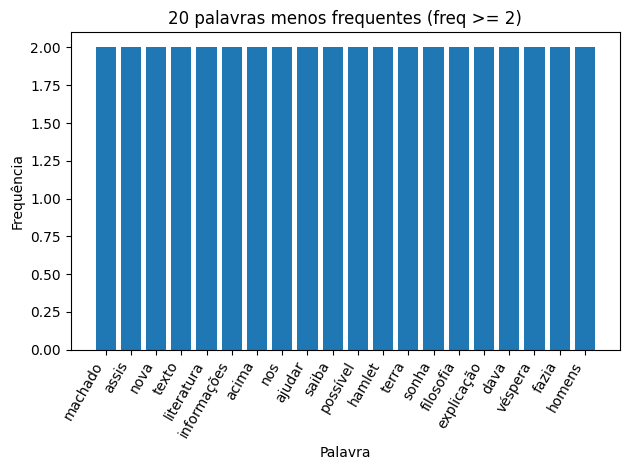

,Palavra,Frequência
0,machado,2
1,assis,2
2,nova,2
3,texto,2
4,literatura,2
5,informações,2
6,acima,2
7,nos,2
8,ajudar,2
9,saiba,2


In [ ]:
# Gráficos das Palavras menos frequentes

# Excluindo palavras com hapax (freq = 1) para evitar ruído de palavras que aparecem apenas uma vez, 
# focando em palavras que aparecem pelo menos 2 vezes para ter uma visão mais clara das palavras raras mas ainda relevantes.

not_included = ['http', 'www', 'com', 'br', 'org', 'net', 'usp']  # Palavra que estavam no rodapé do arquivo
min_freq = 2
raras = [(w, c) for w, c in contagem.items() if c >= min_freq and w not in not_included]
raras_ordenadas = sorted(raras, key=lambda x: x[1])  

df_raras = pd.DataFrame(raras_ordenadas[:20], columns=["Palavra", "Frequência"])

plt.figure()
plt.bar(df_raras["Palavra"], df_raras["Frequência"])
plt.title(f"20 palavras menos frequentes (freq >= {min_freq})")
plt.xlabel("Palavra")
plt.ylabel("Frequência")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

df_raras

In [18]:
# Respaldo para resposta TC.4

resumo = f"""
Resumo quantitativo do livro:
- Total de palavras (tokens): {total_tokens}
- Palavras diferentes (vocabulário): {vocab}
- TTR (vocab/total): {trr:.4f}
- Hapax (freq=1): {hapax} (Hapax/Vocab: {hapax_ratio:.4f})

Estrutura frasal:
- Sentenças analisadas: {len(tamanhos_sentencas)}
- Média de palavras por sentença (livro): {sum(tamanhos_sentencas)/len(tamanhos_sentencas):.2f}
- Média de palavras por expressão corrente: {sum(tam_exp)/len(tam_exp):.2f}

Interpretação:
- Livros literários tendem a apresentar sentenças mais longas e maior variedade lexical,
  refletida em vocabulário maior e muitas palavras raras (hapax).
- Expressões cotidianas costumam ser curtas, repetitivas e com vocabulário mais restrito.
"""
print(resumo)


Resumo quantitativo do livro:
- Total de palavras (tokens): 3320
- Palavras diferentes (vocabulário): 1183
- TTR (vocab/total): 0.3563
- Hapax (freq=1): 807 (Hapax/Vocab: 0.6822)

Estrutura frasal:
- Sentenças analisadas: 217
- Média de palavras por sentença (livro): 15.30
- Média de palavras por expressão corrente: 3.50

Interpretação:
- Livros literários tendem a apresentar sentenças mais longas e maior variedade lexical,
  refletida em vocabulário maior e muitas palavras raras (hapax).
- Expressões cotidianas costumam ser curtas, repetitivas e com vocabulário mais restrito.

